Ethan Ho
017157582
CMPE 188

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFE
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix

In [5]:
fishData = pd.read_csv("E:/vs/school/CMPE_188/data/FishDataset.csv")
fishData.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [7]:
fishData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


Seems to be no NaN values to remove, however we can get rid of species.

In [17]:
df = fishData.drop(["Species"], axis=1)
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,158.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,1.831072,26.247170,28.415723,31.227044,8.970994,4.417486
std,0.247439,9.996441,10.716328,11.610246,4.286208,1.685804
min,1.020634,7.500000,8.400000,8.800000,1.728400,1.047600
25%,1.757456,19.050000,21.000000,23.150000,5.944800,3.385650
50%,1.893053,25.200000,27.300000,29.400000,7.786000,4.248500
75%,2.011828,32.700000,35.500000,39.650000,12.365900,5.584500
max,2.129247,59.000000,63.400000,68.000000,18.957000,8.142000


The mean is much larger than the other values, so it might be a good idea to normalize the data and place everything between 0 and 1. However I still need to check the distributions.

array([[<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Length1'}>],
       [<Axes: title={'center': 'Length2'}>,
        <Axes: title={'center': 'Length3'}>],
       [<Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Width'}>]], dtype=object)

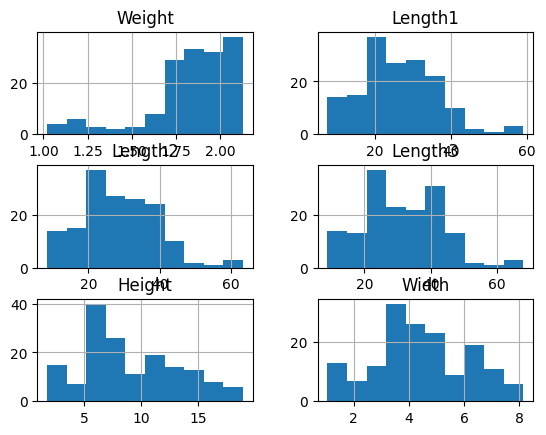

In [18]:
df.hist()

Since the distributions look mainly gaussian, I believe a standardization would fix the skewdness. However we will leave that for later.

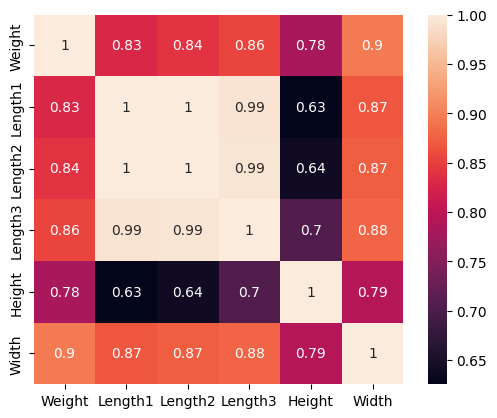

In [22]:
plt.figure()
map = df.corr(method="pearson")
sns.heatmap(map, square=True, annot=True)
plt.show()

<Figure size 640x480 with 0 Axes>

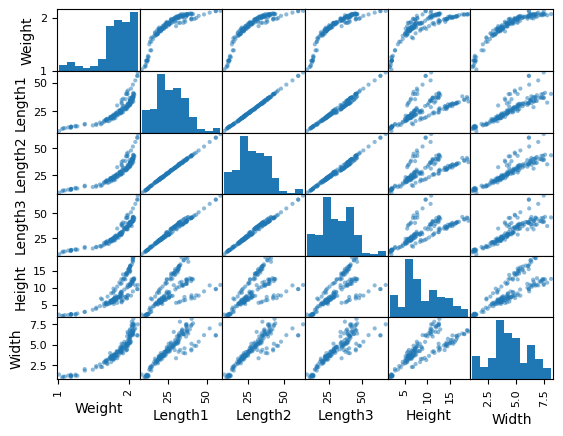

In [23]:
plt.figure()
scatter_matrix(df)
plt.show()

From this small dataset many of the input features have a strong correlation with the weight. I am now expecting to drop only a few, if any, features from the final model. However the relationship seems to stray a little from a linear pattern. I still think linear regression should be able to do a good enough job however. (I also didnt learn a non-linear method yet)